# Phase 6: Final Model Comparison & Conclusion
In this final phase, we re-instantiate our three models (Decision Tree, Naïve Bayes, and Logistic Regression) on the SMOTE-balanced dataset. We will then compare them head-to-head using an overlaid ROC curve, side-by-side Confusion Matrices, and a final metrics table.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True})

import warnings
warnings.filterwarnings('ignore')

In [2]:
print("Loading preprocessed dataset...")
df = pd.read_csv('../outputs/processed_imbalanced_data.csv')
X = df.drop('Severity', axis=1)
y = df['Severity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Applying SMOTE to training data...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print("Data ready for final comparison!")

Loading preprocessed dataset...
Applying SMOTE to training data...
Data ready for final comparison!


In [3]:
print("Training Decision Tree...")
dt = DecisionTreeClassifier(max_depth=15, random_state=42)
dt.fit(X_train_balanced, y_train_balanced)

print("Training Naïve Bayes...")
nb = GaussianNB()
nb.fit(X_train_balanced, y_train_balanced)

print("Training Logistic Regression...")
lr = LogisticRegression(multi_class='multinomial', max_iter=1000, n_jobs=-1, random_state=42)
lr.fit(X_train_balanced, y_train_balanced)

print("All models trained successfully!")

Training Decision Tree...
Training Naïve Bayes...
Training Logistic Regression...
All models trained successfully!


In [5]:
# Predictions
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)

y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)

### 1. Final Metrics Summary Table

In [6]:
models = ['Decision Tree', 'Naïve Bayes', 'Logistic Regression']
preds = [y_pred_dt, y_pred_nb, y_pred_lr]

results = []
for name, pred in zip(models, preds):
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, pred, average='weighted', zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
display(results_df.round(4))

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.4691,0.7638,0.4691,0.5436
Naïve Bayes,0.0661,0.7700,0.0661,0.0775
Logistic Regression,0.4476,0.7635,0.4476,0.5282


### 2. Overlaid ROC Curves

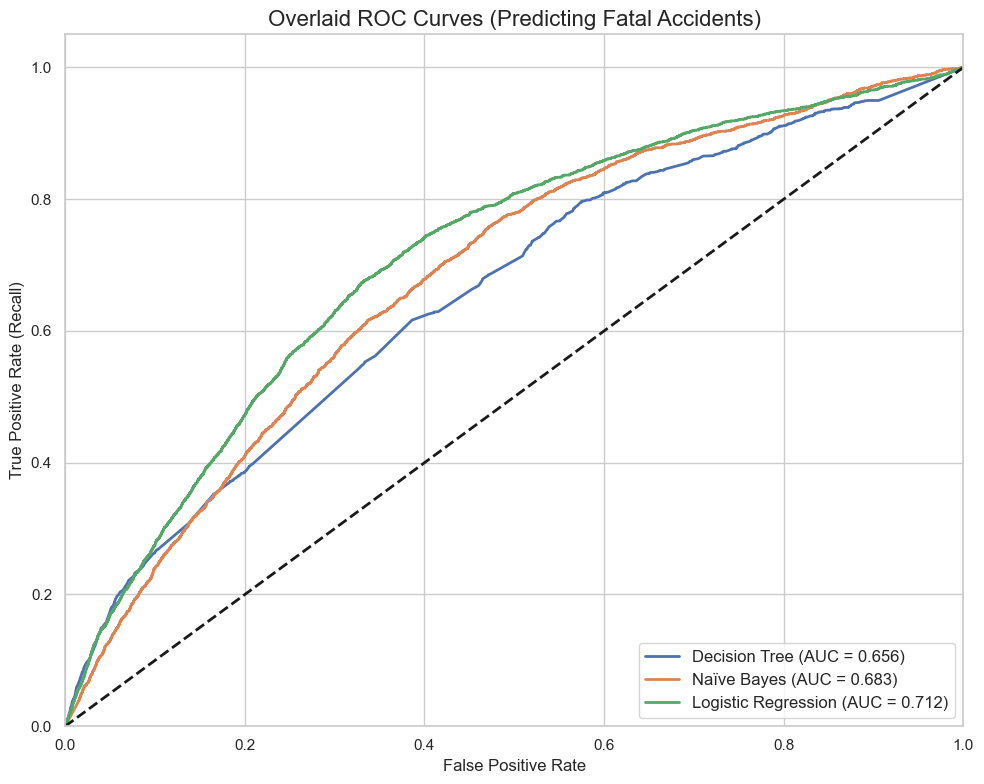

In [7]:
y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4])
fatal_idx = 3 # Severity 4

fpr_dt, tpr_dt, _ = roc_curve(y_test_bin[:, fatal_idx], y_prob_dt[:, fatal_idx])
fpr_nb, tpr_nb, _ = roc_curve(y_test_bin[:, fatal_idx], y_prob_nb[:, fatal_idx])
fpr_lr, tpr_lr, _ = roc_curve(y_test_bin[:, fatal_idx], y_prob_lr[:, fatal_idx])

plt.figure(figsize=(10, 8))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc(fpr_dt, tpr_dt):.3f})', lw=2)
plt.plot(fpr_nb, tpr_nb, label=f'Naïve Bayes (AUC = {auc(fpr_nb, tpr_nb):.3f})', lw=2)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.3f})', lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Overlaid ROC Curves (Predicting Fatal Accidents)', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.show()

### 3. Side-by-Side Confusion Matrices

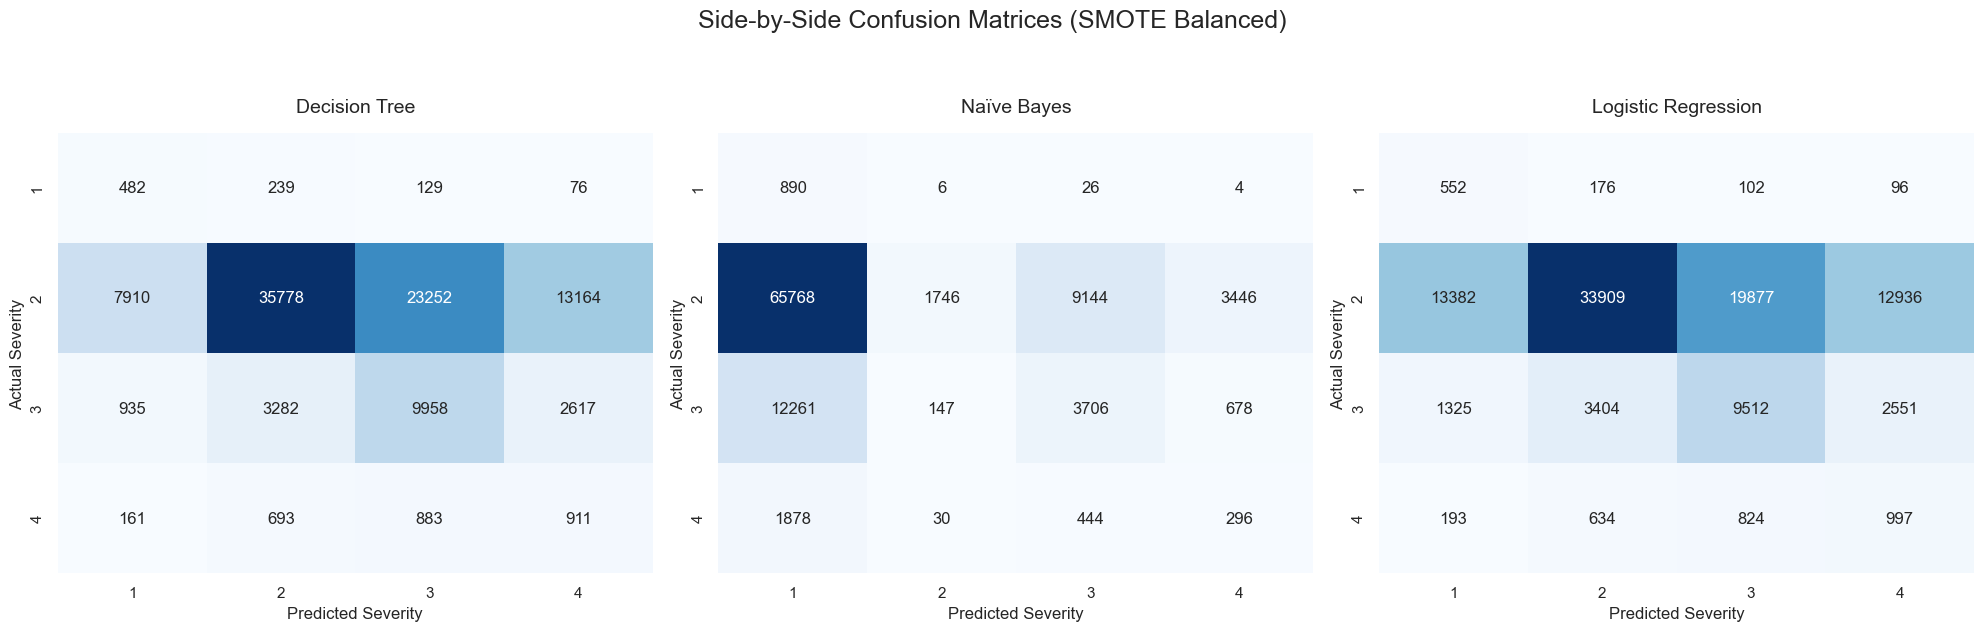

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = ['Decision Tree', 'Naïve Bayes', 'Logistic Regression']

for ax, pred, title in zip(axes, preds, titles):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=[1,2,3,4], yticklabels=[1,2,3,4], cbar=False)
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel('Predicted Severity')
    ax.set_ylabel('Actual Severity')

plt.suptitle('Side-by-Side Confusion Matrices (SMOTE Balanced)', fontsize=18, y=1.05)
plt.show()